# Project Details


*   Organization: Corizo Edutech Pvt. Ltd.
*   Intern Name: Shruti Sanjay Sable
*   Project Type: Minor Project





# Project Objectives
It will examine specific data from some body measurements conducted within the NHANES 2020 survey for males and females. The goal will be to apply NumPy and Matplotlib libraries with a focus on exploring and analyzing data distribution, summarizing statistics, identifying and developing extra ratios based on anthropometric variables, and presenting data visualization based on variable correlations. All interpretations will be based on sound statistical concepts and ideas.

# 1. Initial Data Loading and Setup

This code downloads the NHANES 2020 male and female body-measurement datasets, loads them into pandas DataFrames, and converts them into NumPy matrices (male and female) for further statistical analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request

In [ ]:
base_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/"
files = ["nhanes_adult_male_bmx_2020.csv", "nhanes_adult_female_bmx_2020.csv"]

for f in files:
  urllib.request.urlretrieve(base_url + f, f)

In [ ]:
# Load the CSV files into pandas DataFrames, handling headers and comments
df_male = pd.read_csv("nhanes_adult_male_bmx_2020.csv", delimiter=",", comment='#')
df_female = pd.read_csv("nhanes_adult_female_bmx_2020.csv", delimiter=",", comment='#')

# Convert the DataFrames to NumPy arrays
male = df_male.to_numpy()
female = df_female.to_numpy()

In [ ]:
print("Adult Female Body Measurements (NHANES 2020)")
print(df_female.head())
print("Adult Male Body Measurements (NHANES 2020)")
print(df_male.head())

Adult Female Body Measurements (NHANES 2020)
   BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST
0   97.1  160.2     34.7    40.8     35.8   126.1     117.9
1   91.1  152.7     33.5    33.0     38.5   125.5     103.1
2   73.0  161.2     37.4    38.0     31.8   106.2      92.0
3   61.7  157.4     38.0    34.7     29.0   101.0      90.5
4   55.4  154.6     34.6    34.0     28.3    92.5      73.2
Adult Male Body Measurements (NHANES 2020)
   BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST
0   98.8  182.3     42.0    40.1     38.2   108.2     120.4
1   74.3  184.2     41.1    41.0     30.2    94.5      86.8
2  103.7  185.3     47.0    44.0     32.0   107.8     109.6
3   86.0  167.8     39.5    38.4     29.0   106.4     108.3
4   99.4  181.6     40.4    39.9     36.0   120.2     107.0


The datasets were successfully downloaded and loaded. The DataFrames display the expected seven measurement variables, and their conversion into NumPy matrices prepares the data for subsequent numerical operations in the project.

# 2. Data Overview and Weight Distribution Analysis

This section explores the weight distributions of male and female participants using histograms and boxplots.

## 2.1 Female and Male Weight Histograms

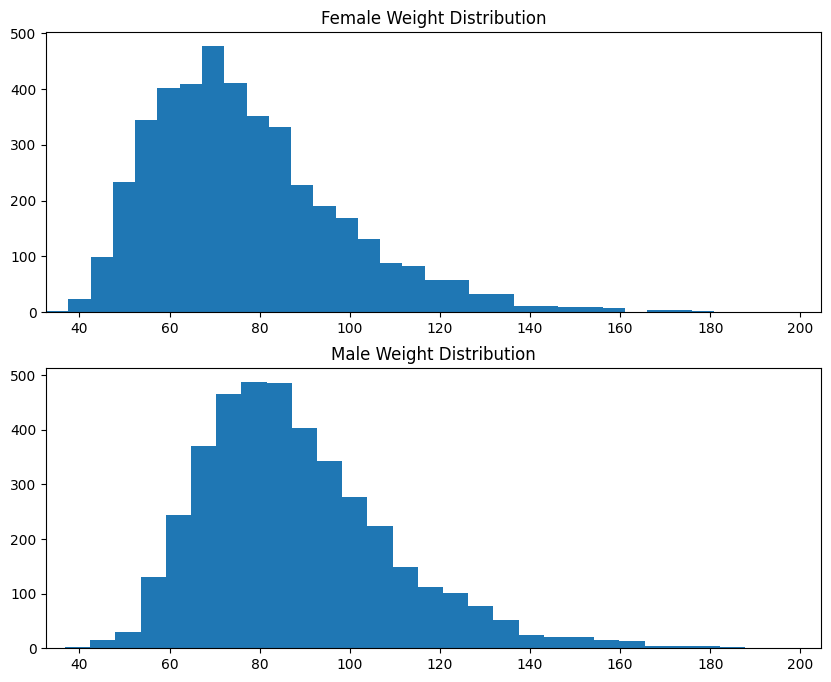

In [ ]:
plt.figure(figsize=(10,8))

# Calculate overall min and max weight for consistent x-axis
min_weight = min(female[:,0].min(), male[:,0].min())
max_weight = max(female[:,0].max(), male[:,0].max())

plt.subplot(2,1,1)
plt.hist(female[:,0], bins=30)
plt.title("Female Weight Distribution")
plt.xlim(min_weight, max_weight) # Apply x-limit here

plt.subplot(2,1,2)
plt.hist(male[:,0], bins=30)
plt.title("Male Weight Distribution")
plt.xlim(min_weight, max_weight) # Apply x-limit here
plt.show()

## 2.2 Female and Male Weight Boxplot

/tmp/ipython-input-37067521.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_weights, male_weights],


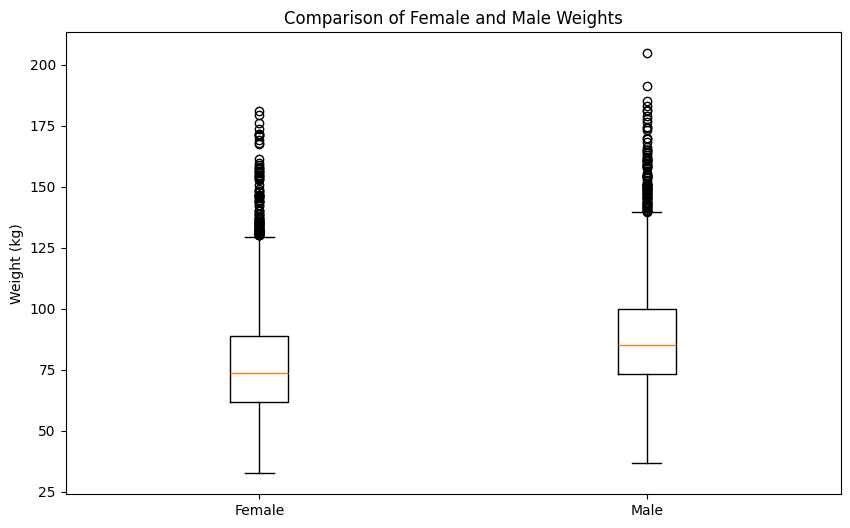

In [ ]:
female_weights = female[:, 0]
male_weights = male[:, 0]

plt.figure(figsize=(10,6))

plt.boxplot([female_weights, male_weights],
            labels=["Female", "Male"])

plt.title("Comparison of Female and Male Weights")
plt.ylabel("Weight (kg)")

plt.show()


**RESULT**: The histograms show that both male and female weight distributions are right-skewed, with males generally weighing more on average. The boxplot confirms this difference, showing a higher median and greater spread among males.

## 2.3 Statistical Summary of Weights

In [ ]:
import scipy.stats as stats

# --- Female Weights --- #
print("Female Weights Statistics:")
female_mean = np.mean(female_weights)
female_median = np.median(female_weights)
female_std = np.std(female_weights)
female_var = np.var(female_weights)
female_iqr = stats.iqr(female_weights)
female_skew = stats.skew(female_weights)
female_kurt = stats.kurtosis(female_weights)

print(f"Mean: {female_mean:.2f}")
print(f"Median: {female_median:.2f}")
print(f"Standard Deviation: {female_std:.2f}")
print(f"Variance: {female_var:.2f}")
print(f"IQR: {female_iqr:.2f}")
print(f"Skewness: {female_skew:.2f}")
print(f"Kurtosis: {female_kurt:.2f}\n")

# --- Male Weights --- #
print("Male Weights Statistics:")
male_mean = np.mean(male_weights)
male_median = np.median(male_weights)
male_std = np.std(male_weights)
male_var = np.var(male_weights)
male_iqr = stats.iqr(male_weights)
male_skew = stats.skew(male_weights)
male_kurt = stats.kurtosis(male_weights)

print(f"Mean: {male_mean:.2f}")
print(f"Median: {male_median:.2f}")
print(f"Standard Deviation: {male_std:.2f}")
print(f"Variance: {male_var:.2f}")
print(f"IQR: {male_iqr:.2f}")
print(f"Skewness: {male_skew:.2f}")
print(f"Kurtosis: {male_kurt:.2f}")

Female Weights Statistics:
Mean: 77.40
Median: 73.60
Standard Deviation: 21.54
Variance: 464.08
IQR: 27.10
Skewness: 1.03
Kurtosis: 1.40

Male Weights Statistics:
Mean: 88.36
Median: 85.00
Standard Deviation: 21.42
Variance: 458.77
IQR: 26.50
Skewness: 0.98
Kurtosis: 1.47


**The numerical statistics support these observations:**

1. Males have higher mean and median weights than females.

2. Dispersion (standard deviation, variance, and IQR) is greater in males, indicating more variability.

3. Both groups show positive skewness, consistent with the long right tail.

4. Kurtosis values suggest the presence of heavier individuals acting as outliers, more observed among males.

Overall, male weights are heavier, more variable, and exhibit slightly stronger right skewness compared to female weights.

# 3. Body Mass Index (BMI) Calculation

This step computes the Body Mass Index (BMI) for each female participant using the standard formula. Height values are converted from centimeters to meters before applying the calculation. The resulting BMI values are added as a new column in the DataFrame for further analysis.

In [ ]:
df_female['BMI'] = df_female['BMXWT'] / (df_female['BMXHT'] / 100)**2
print(df_female.head())

   BMXWT  BMXHT  BMXARML  BMXLEG  BMXARMC  BMXHIP  BMXWAIST        BMI
0   97.1  160.2     34.7    40.8     35.8   126.1     117.9  37.835041
1   91.1  152.7     33.5    33.0     38.5   125.5     103.1  39.069720
2   73.0  161.2     37.4    38.0     31.8   106.2      92.0  28.092655
3   61.7  157.4     38.0    34.7     29.0   101.0      90.5  24.904378
4   55.4  154.6     34.6    34.0     28.3    92.5      73.2  23.178791


The BMI column was successfully added to the female dataset. The preview of the updated DataFrame confirms that each row now includes a calculated BMI value derived from weight and height measurements.

# 4. Standardization of Female Anthropometric Data

This section standardizes the female anthropometric data using z-scores to enable fair comparisons across variables with different units and scales. After standardization, a scatterplot matrix is generated to visualize relationships between key variables, followed by a correlation analysis using both Pearson’s and Spearman’s methods.

## 4.1 Data Selection and Z-Score Standardization

The following code computes the z-scores for each variable in the female dataset by subtracting the mean and dividing by the standard deviation. A standardized scatterplot matrix visualizes relationships between key variables, followed by a correlation analysis done through Pearson’s and Spearman’s methods.

In [ ]:
# Calculate the mean and standard deviation for each column of the female matrix
female_means = np.mean(female, axis=0)
female_stds = np.std(female, axis=0)

# Compute the z-scores for each column
zfemale = (female - female_means) / female_stds

print("First 5 rows of the standardized female matrix (zfemale):")
print(zfemale[:5])

First 5 rows of the standardized female matrix (zfemale):
[[ 0.91429508  0.00895038 -0.56739463  1.13298804  0.55084546  1.08316157
   1.11578462]
 [ 0.63577599 -1.05306843 -1.07893145 -1.29349161  1.03221804  1.04475528
   0.265089  ]
 [-0.2044233   0.15055289  0.5835632   0.26194406 -0.1622991  -0.19064688
  -0.37293272]
 [-0.7289676  -0.38753664  0.83933161 -0.76464348 -0.66150029 -0.52350135
  -0.45915188]
 [-1.02141265 -0.78402366 -0.6100227  -0.98240447 -0.78630059 -1.06759039
  -1.45354609]]


In [ ]:
selected_columns = ['BMXHT', 'BMXWT', 'BMXWAIST', 'BMXHIP', 'BMI']
df_female_selected = df_female[selected_columns]

# Calculate mean and standard deviation for each selected column
female_means_selected = df_female_selected.mean()
female_stds_selected = df_female_selected.std()

# Standardize the selected columns (compute z-scores)
df_female_standardized = (df_female_selected - female_means_selected) / female_stds_selected

print("First 5 rows of the standardized female DataFrame (df_female_standardized):")
print(df_female_standardized.head())

First 5 rows of the standardized female DataFrame (df_female_standardized):
      BMXHT     BMXWT  BMXWAIST    BMXHIP       BMI
0  0.008949  0.914187  1.115652  1.083033  0.996850
1 -1.052944  0.635701  0.265058  1.044632  1.156038
2  0.150535 -0.204399 -0.372889 -0.190624 -0.259244
3 -0.387491 -0.728881 -0.459097 -0.523439 -0.670311
4 -0.783931 -1.021292 -1.453374 -1.067464 -0.892793


The standardized matrix (zfemale) was successfully created. The first few rows confirm that all variables now follow a common scale, centered at zero with unit variance.

## 4.2 Scatterplot Matrix of Standardized Female Data

This pairplot visualizes pairwise relationships among the standardized height, weight, waist circumference, hip circumference, and BMI measurements. It helps identify potential linear and non-linear associations between the variables.

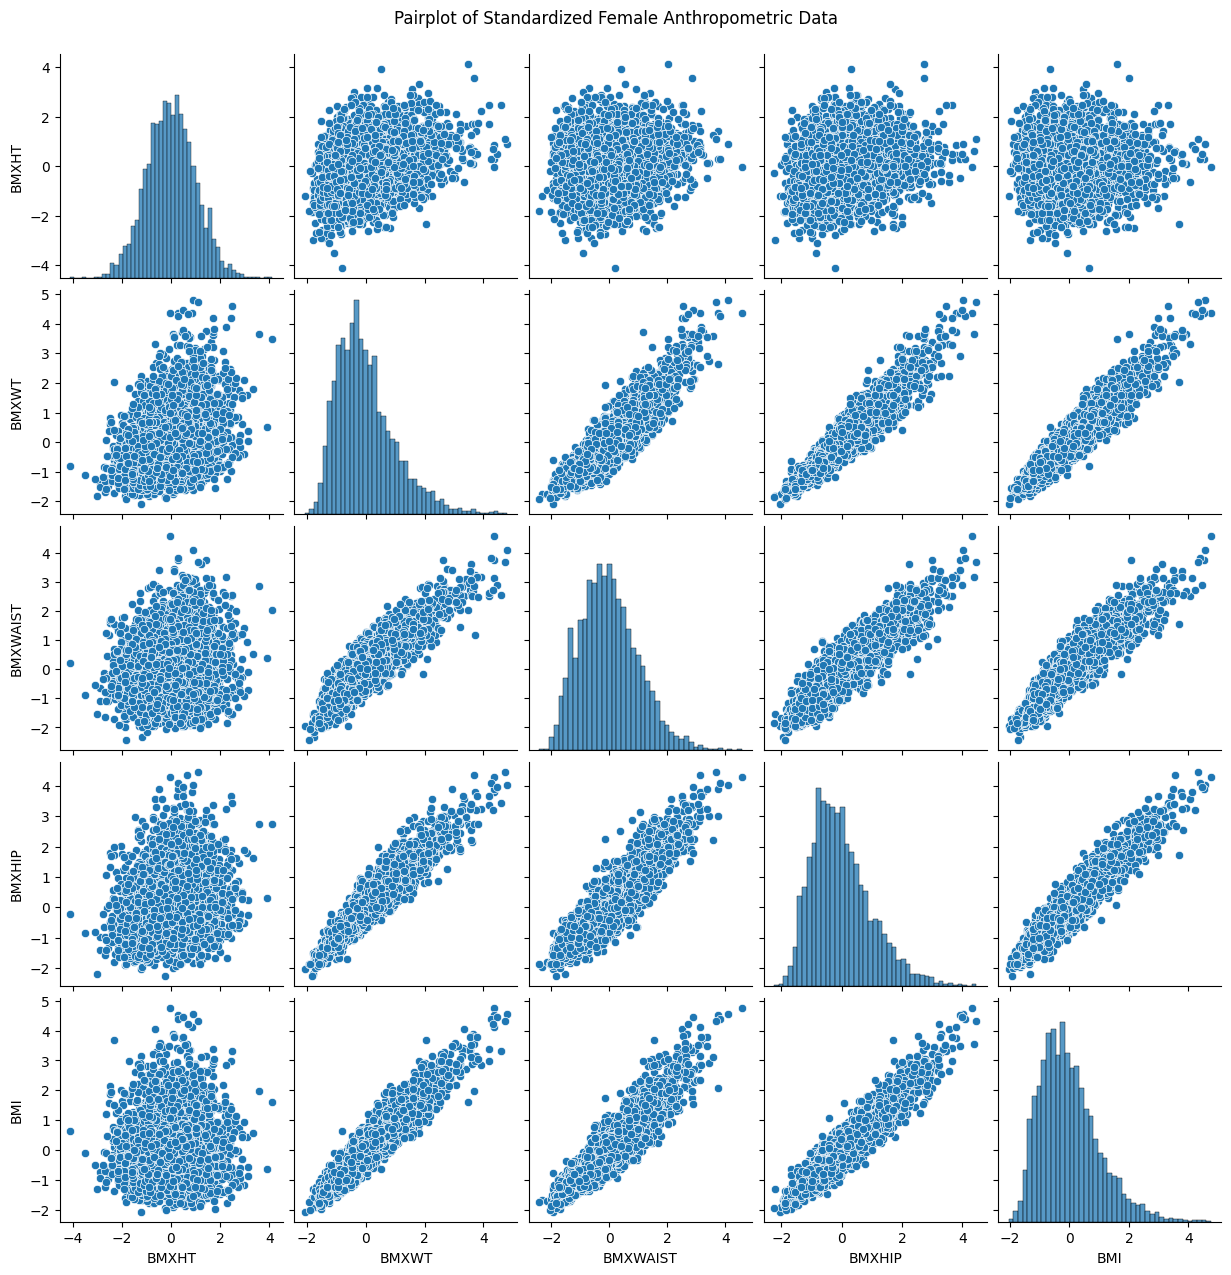

In [ ]:
# Create a scatterplot matrix (pairplot) for the standardized female data
sns.pairplot(df_female_standardized)
plt.suptitle('Pairplot of Standardized Female Anthropometric Data', y=1.02) # Add a title to the entire plot
plt.show()


The pairplot reveals strong positive relationships between weight, waist circumference, hip circumference, and BMI. Height shows weaker associations with these measures. The standardized scaling ensures that all variables contribute comparably to the visual interpretation.

## 4.3 Correlation Analysis of Standardized Female Data

This section computes Pearson’s and Spearman’s correlation matrices to quantify the strength and direction of relationships among the standardized variables. Pearson’s method captures linear relationships, while Spearman’s method evaluates monotonic trends.

In [ ]:
# Calculate Pearson's correlation matrix
pearson_corr = df_female_standardized.corr(method='pearson')

# Calculate Spearman's correlation matrix
spearman_corr = df_female_standardized.corr(method='spearman')

print("Pearson's Correlation Matrix:")
print(pearson_corr)
print("\nSpearman's Correlation Matrix:")
print(spearman_corr)

Pearson's Correlation Matrix:
             BMXHT     BMXWT  BMXWAIST    BMXHIP       BMI
BMXHT     1.000000  0.345496  0.126547  0.202895  0.033077
BMXWT     0.345496  1.000000  0.904550  0.946553  0.945900
BMXWAIST  0.126547  0.904550  1.000000  0.897407  0.921198
BMXHIP    0.202895  0.946553  0.897407  1.000000  0.944199
BMI       0.033077  0.945900  0.921198  0.944199  1.000000

Spearman's Correlation Matrix:
             BMXHT     BMXWT  BMXWAIST    BMXHIP       BMI
BMXHT     1.000000  0.338860  0.108587  0.205405  0.019897
BMXWT     0.338860  1.000000  0.900169  0.946634  0.937999
BMXWAIST  0.108587  0.900169  1.000000  0.888037  0.923114
BMXHIP    0.205405  0.946634  0.888037  1.000000  0.934196
BMI       0.019897  0.937999  0.923114  0.934196  1.000000


Both correlation matrices show strong positive associations between weight, waist circumference, hip circumference, and BMI, indicating that increases in one measure are generally accompanied by increases in the others. Height exhibits weaker correlations with the remaining variables. The similarity of Pearson and Spearman values suggests that the relationships are linear.

# 5. Calculation of Waist-to-Height and Waist-to-Hip Ratios

This section computes two commonly used anthropometric ratios—waist-to-height ratio and waist-to-hip ratio—for both female and male participants. These ratios are important indicators of body fat distribution and potential metabolic risk.

In [ ]:
# Column indices for female and male matrices
# BMXWT (0), BMXHT (1), BMXARML (2), BMXLEG (3), BMXARMC (4), BMXHIP (5), BMXWAIST (6)

# --- For Female Participants ---
# Calculate Waist Circumference to Height Ratio for females
female_waist_to_height_ratio = female[:, 6] / female[:, 1]

# Calculate Waist Circumference to Hip Circumference Ratio for females
female_waist_to_hip_ratio = female[:, 6] / female[:, 5]

# Add these new ratios as columns to the female matrix
female = np.c_[female, female_waist_to_height_ratio, female_waist_to_hip_ratio]

print("Updated female matrix shape:", female.shape)
print("First 5 rows of updated female matrix (with new ratios):")
print(female[:5])

# --- For Male Participants ---
# Calculate Waist Circumference to Height Ratio for males
male_waist_to_height_ratio = male[:, 6] / male[:, 1]

# Calculate Waist Circumference to Hip Circumference Ratio for males
male_waist_to_hip_ratio = male[:, 6] / male[:, 5]

# Add these new ratios as columns to the male matrix
male = np.c_[male, male_waist_to_height_ratio, male_waist_to_hip_ratio]

print("\nUpdated male matrix shape:", male.shape)
print("First 5 rows of updated male matrix (with new ratios):")
print(male[:5])

Updated female matrix shape: (4221, 9)
First 5 rows of updated female matrix (with new ratios):
[[ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9          0.73595506   0.93497224]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1          0.67518009   0.82151394]
 [ 73.         161.2         37.4         38.          31.8
  106.2         92.           0.5707196    0.86629002]
 [ 61.7        157.4         38.          34.7         29.
  101.          90.5          0.57496823   0.8960396 ]
 [ 55.4        154.6         34.6         34.          28.3
   92.5         73.2          0.47347995   0.79135135]]

Updated male matrix shape: (4081, 9)
First 5 rows of updated male matrix (with new ratios):
[[ 98.8        182.3         42.          40.1         38.2
  108.2        120.4          0.66044981   1.11275416]
 [ 74.3        184.2         41.1         41.          30.2
   94.5         86.8          0.47122693   0.91851852]
 [103.

Both ratios were successfully calculated for male and female participants and added as new columns to their respective matrices. The updated matrix shapes confirm the inclusion of two additional variables. The preview of the first five rows shows that each participant now has computed waist-to-height and waist-to-hip ratios, which will be used in the next section to compare the distributions between males and females.

# 6. Comparison of Ratios by Sex (Boxplot)

/tmp/ipython-input-3517253123.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_waist_to_height_ratio, female_waist_to_hip_ratio, male_waist_to_height_ratio, male_waist_to_hip_ratio],


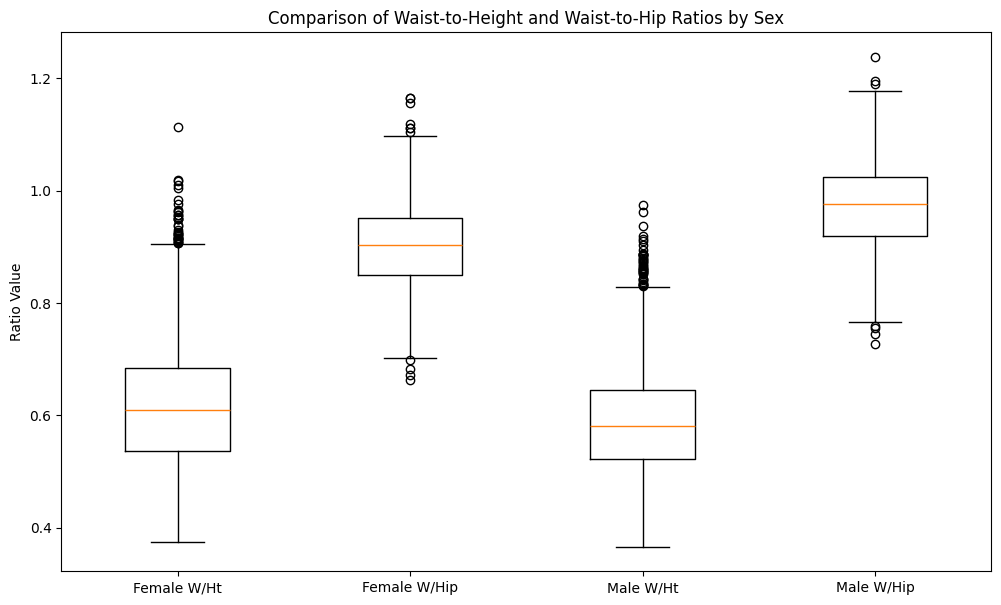

In [ ]:
female_waist_to_height_ratio = female[:, 7]
female_waist_to_hip_ratio = female[:, 8]
male_waist_to_height_ratio = male[:, 7]
male_waist_to_hip_ratio = male[:, 8]

plt.figure(figsize=(12,7))

plt.boxplot([female_waist_to_height_ratio, female_waist_to_hip_ratio, male_waist_to_height_ratio, male_waist_to_hip_ratio],
            labels=["Female W/Ht", "Female W/Hip", "Male W/Ht", "Male W/Hip"])

plt.title("Comparison of Waist-to-Height and Waist-to-Hip Ratios by Sex")
plt.ylabel("Ratio Value")

plt.show()

The boxplot highlights clear differences between males and females for both ratios. Female participants typically exhibit lower waist-to-height and waist-to-hip ratios compared to males. Male ratios show slightly greater spread, indicating more variability in central fat distribution. These visual patterns support the general observation that males tend to accumulate more abdominal fat relative to body size.

# 7. Advantages and Disadvantages of Anthropometric Metrics

**Body Mass Index**

**Advantages**

1. Easy and rapid calculation based solely on height and weight.

2. Helpful for large population screening and epidemiological research.

3. Universal acceptance and standardization.

**Disadvantages**

1. It does not differentiate between Fat Mass and Muscle Mass.

2. Not possible to evaluate fat distribution.

3. May inaccurately classify athletes, elderly subjects, and people with unusual body composition.

**Waist-to-Height Ratio**

**Advantages**

1. Takes into account visceral fat, an important risk factor for metabolism and cardiovascular disease.

2. More reliable than BMI for identifying central obesity.

3. Universal, regardless of age, sex, and ethnic background, with a uniform threshold value (for instance, WHTR > 0.5).

**Disadvantages**

1. Requires exact measurement around waist. May differ with technique.

2. Less commonly employed within medical practice compared with BMI.

**Waist-to-Hip Ratio**

**Advantages**

1. It measures fat distribution and separates central and peripheral distribution.

2. Helpful Visceral Fat/Related Health Risks Indicator.

3. Helpful for comparing body shape differences among people.

**Disadvantages**

1. The hip measurement may be influenced by bone distribution and muscle mass.

2. Increased measurement variability because two measurements were necessary.

3. The thresholds may be different for different populations.

# 8. Analysis of Extreme BMI Cases

This section identifies the five female participants with the lowest and highest standardized BMI values. Their standardized anthropometric measurements are extracted to examine how extreme BMI values correspond to variations in height, weight, waist circumference, hip circumference, and overall body proportions.

In [ ]:
# Get the indices that would sort the standardized BMI values
sorted_bmi_indices = np.argsort(df_female_standardized['BMI'].values)

# Get the indices of the 5 persons with the lowest BMI
lowest_bmi_5_indices = sorted_bmi_indices[:5]

# Get the indices of the 5 persons with the highest BMI
highest_bmi_5_indices = sorted_bmi_indices[-5:]

print("Standardized body measurements for the 5 persons with the lowest BMI:")
print(df_female_standardized.iloc[lowest_bmi_5_indices])

print("\nStandardized body measurements for the 5 persons with the highest BMI:")
print(df_female_standardized.iloc[highest_bmi_5_indices])

Standardized body measurements for the 5 persons with the lowest BMI:
         BMXHT     BMXWT  BMXWAIST    BMXHIP       BMI
262  -1.222847 -2.079539 -1.941891 -2.040308 -2.049997
3478 -0.189271 -1.879957 -2.056836 -1.854699 -1.994644
2126  1.807088 -1.536491 -1.706253 -1.675491 -1.970650
2753 -0.260064 -1.842826 -1.855682 -2.251517 -1.941546
1209  0.886781 -1.610754 -1.712001 -1.829098 -1.892971

Standardized body measurements for the 5 persons with the highest BMI:
         BMXHT     BMXWT  BMXWAIST    BMXHIP       BMI
2268  0.292121  4.246737  3.816866  4.103970  4.395971
3022  0.504499  4.455602  2.903051  3.982364  4.461483
1472  0.277962  4.348849  3.753646  3.918361  4.514134
1104  0.886781  4.803709  4.081240  4.020766  4.542171
1096 -0.033526  4.362773  4.569757  4.315179  4.761869


The output shows clear contrasts between individuals with extremely low and extremely high BMI values. Participants with low BMI generally have negative z-scores for weight, waist circumference, and hip circumference, indicating measurements below the sample mean. In contrast, individuals with high BMI exhibit strongly positive z-scores for these variables, reflecting greater body mass and larger circumferences. These patterns confirm that BMI variations are closely linked to overall body size and central adiposity.

# References
1. WHO Expert Consultation. Waist-to-hip ratio and waist circumference as indicators of metabolic and cardiovascular risk.
2. World Health Organization (WHO). Body Mass Index (BMI) Classification and Interpretation Guidelines